In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from som_model import GeneralCLASSOM

LOAD CSV FILE WITH TRAIN DATA
check shape and featuresname

In [56]:
df = pd.read_csv("../data/features_full_file_SOM_PPG_centroid.csv")

df_som = df[['HR', 'HRV_RMSSD', 'HRV_SDNN']].copy()
# df_som = df.copy()
print("Shape:", df_som.shape)
print("\nColumns:")
print(df_som.columns)

print("\nDescribe:")
print(df_som.describe())

Shape: (104976, 3)

Columns:
Index(['HR', 'HRV_RMSSD', 'HRV_SDNN'], dtype='str')

Describe:
                  HR      HRV_RMSSD       HRV_SDNN
count  104976.000000  104976.000000  104976.000000
mean       79.505632      47.735581      57.832439
std        11.658813      16.844031      23.335480
min        52.600662       8.021961      10.176887
25%        71.358806      34.764013      40.440871
50%        78.205153      47.673831      54.540574
75%        86.366197      60.566768      72.229098
max       155.145444     100.415802     170.593132


FUNCTION FOR TOPOGRAPIC_ERROR 

In [57]:
def topographic_error(som, data):

    error_count = 0

    for x in data:

        # avstånd till alla neuroner
        weights = som.get_weights()
        dists = np.linalg.norm(weights - x, axis=2)

        # hitta BMU och second BMU
        bmu_idx = np.unravel_index(np.argmin(dists), dists.shape)

        dists[bmu_idx] = np.inf
        second_bmu = np.unravel_index(np.argmin(dists), dists.shape)

        # kontrollera om de är grannar
        if max(abs(bmu_idx[0]-second_bmu[0]),
               abs(bmu_idx[1]-second_bmu[1])) > 1:
            error_count += 1

    return error_count / len(data)

CREATE SOM MODEL PARAMETERS

OUTPUT: SUMMARY OF DIFFERENT PARAMETERS

In [29]:
som_clas_200 = GeneralCLASSOM(

    x=30,
    y=30,
    input_len=3,

    sigma=6,
    learning_rate=0.1,

    random_seed=42
)

som_clas_200.get_summary()

{'x': 30,
 'y': 30,
 'input_len': 3,
 'sigma': 6,
 'learning_rate': 0.1,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

TRAIN MODELL 

Change parameters

iterations:

mode

pca

In [58]:
som_clas_200.train(

   df_som,

    iterations=300000,
    mode="batch",

    use_pca=True,
    verbose=True
)

 [ 300000 / 300000 ] 100% - 0:00:00 left 
 quantization error: 0.05637208345028047
Training completed (300000 iterations)


SOM WEIGHTS MIN/MAX 

CHECK SO MAX/MIN SCALER WORKS 

In [59]:
print("SOM weights min/max:")
weights = som_clas_200.som.get_weights()
print(weights.min(), weights.max())

SOM weights min/max:
0.06885424378575361 0.776815558269815


SOM NEURON ANALYSIS

1. Feature-wise variation
Each feature should show variation across the map.

2. Weight planes (component maps)
Each feature is visualized across the SOM grid.

3. Neuron variance
Measures how much each neuron varies across features.

4. Dead neurons
Neurons with very low variance

5. Weight distribution
Histogram of all weights

=== BASIC INFO ===
Shape: (30, 30, 3)
Global min: 0.06885424378575361
Global max: 0.776815558269815
Global variance: 0.02479850188680398

=== FEATURE-WISE RANGE ===
Feature 0: min=0.111, max=0.539, var=0.0082
Feature 1: min=0.109, max=0.777, var=0.0327
Feature 2: min=0.069, max=0.620, var=0.0147

=== VISUALIZING WEIGHT PLANES ===


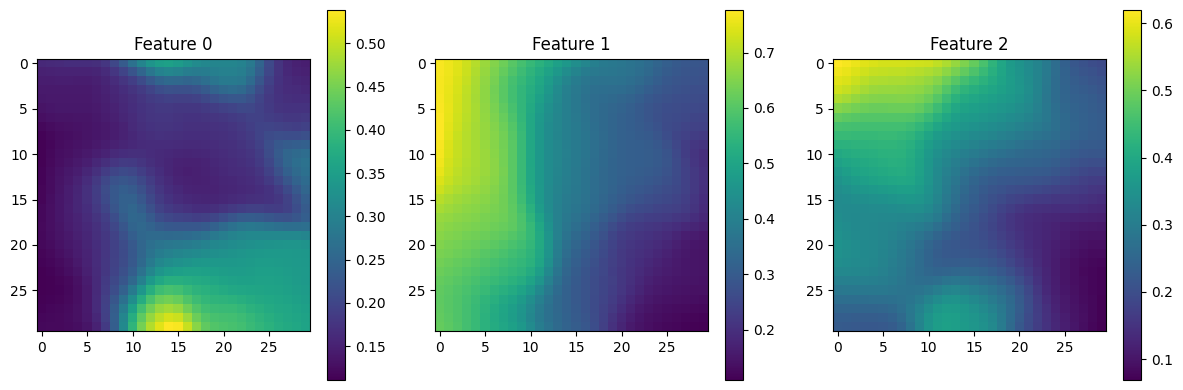


=== NEURON VARIATION ===
Neuron variance stats:
min: 7.327979437778457e-06
max: 0.0725480068030996
mean: 0.018134444392298724


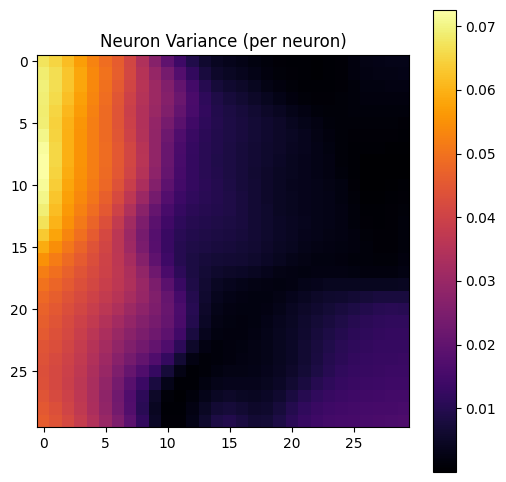


=== LOW VARIANCE NEURONS ===
Low-variance neurons (<5th percentile): 45


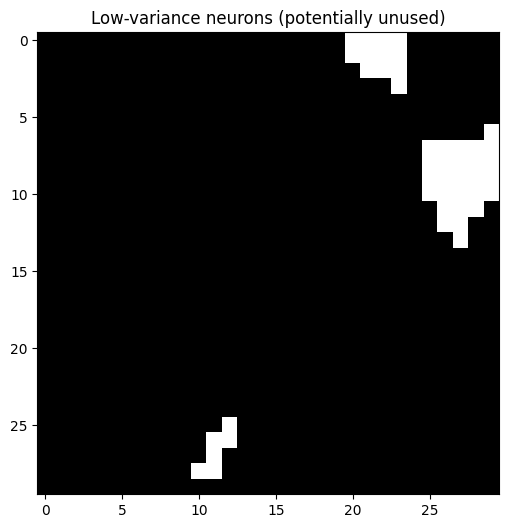


=== WEIGHT DISTRIBUTION ===


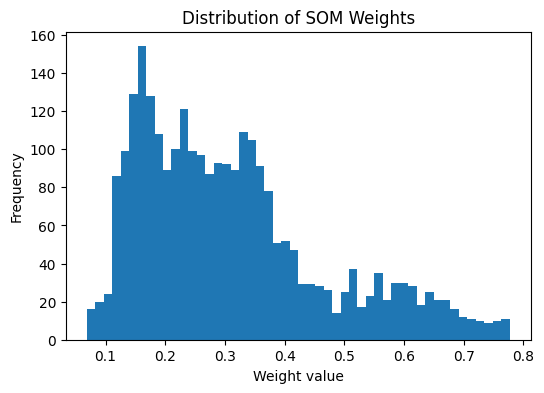

In [60]:
# === Hämta weights ===
weights = som_clas_200.som.get_weights()  # shape: (x, y, features)

print("=== BASIC INFO ===")
print("Shape:", weights.shape)
print("Global min:", weights.min())
print("Global max:", weights.max())
print("Global variance:", np.var(weights))

# =========================================
# 1. FEATURE-WISE ANALYS 
# =========================================
print("\n=== FEATURE-WISE RANGE ===")

n_features = weights.shape[2]

for i in range(n_features):
    w = weights[:, :, i]
    print(f"Feature {i}: min={w.min():.3f}, max={w.max():.3f}, var={np.var(w):.4f}")

# =========================================
# 2. VISUALISERA WEIGHT PLANES
# =========================================
print("\n=== VISUALIZING WEIGHT PLANES ===")

fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 4))

for i in range(n_features):
    ax = axes[i] if n_features > 1 else axes
    im = ax.imshow(weights[:, :, i], cmap="viridis")
    ax.set_title(f"Feature {i}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# =========================================
# 3. NEURON VARIATION 
# =========================================
print("\n=== NEURON VARIATION ===")

# variation per neuron (över features)
neuron_variance = np.var(weights, axis=2)

print("Neuron variance stats:")
print("min:", neuron_variance.min())
print("max:", neuron_variance.max())
print("mean:", neuron_variance.mean())

plt.figure(figsize=(6,6))
plt.imshow(neuron_variance, cmap="inferno")
plt.colorbar()
plt.title("Neuron Variance (per neuron)")
plt.show()

# =========================================
# 4. DEAD / LOW-ACTIVITY NEURONS
# =========================================
print("\n=== LOW VARIANCE NEURONS ===")

threshold = np.percentile(neuron_variance, 5)

dead_mask = neuron_variance < threshold
num_dead = np.sum(dead_mask)

print(f"Low-variance neurons (<5th percentile): {num_dead}")

plt.figure(figsize=(6,6))
plt.imshow(dead_mask, cmap="gray")
plt.title("Low-variance neurons (potentially unused)")
plt.show()

# =========================================
# 5. WEIGHT DISTRIBUTION
# =========================================
print("\n=== WEIGHT DISTRIBUTION ===")

plt.figure(figsize=(6,4))
plt.hist(weights.flatten(), bins=50)
plt.title("Distribution of SOM Weights")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.show()

In [61]:
scaled_train = som_clas_200.scaler.transform(df_som)

qe = som_clas_200.som.quantization_error(scaled_train)

te = topographic_error(
    som_clas_200.som,
    scaled_train
)

print("Quantization Error:", qe)
print("Topographic Error:", te)

Quantization Error: 0.05637208345028047
Topographic Error: 0.04626771833561957


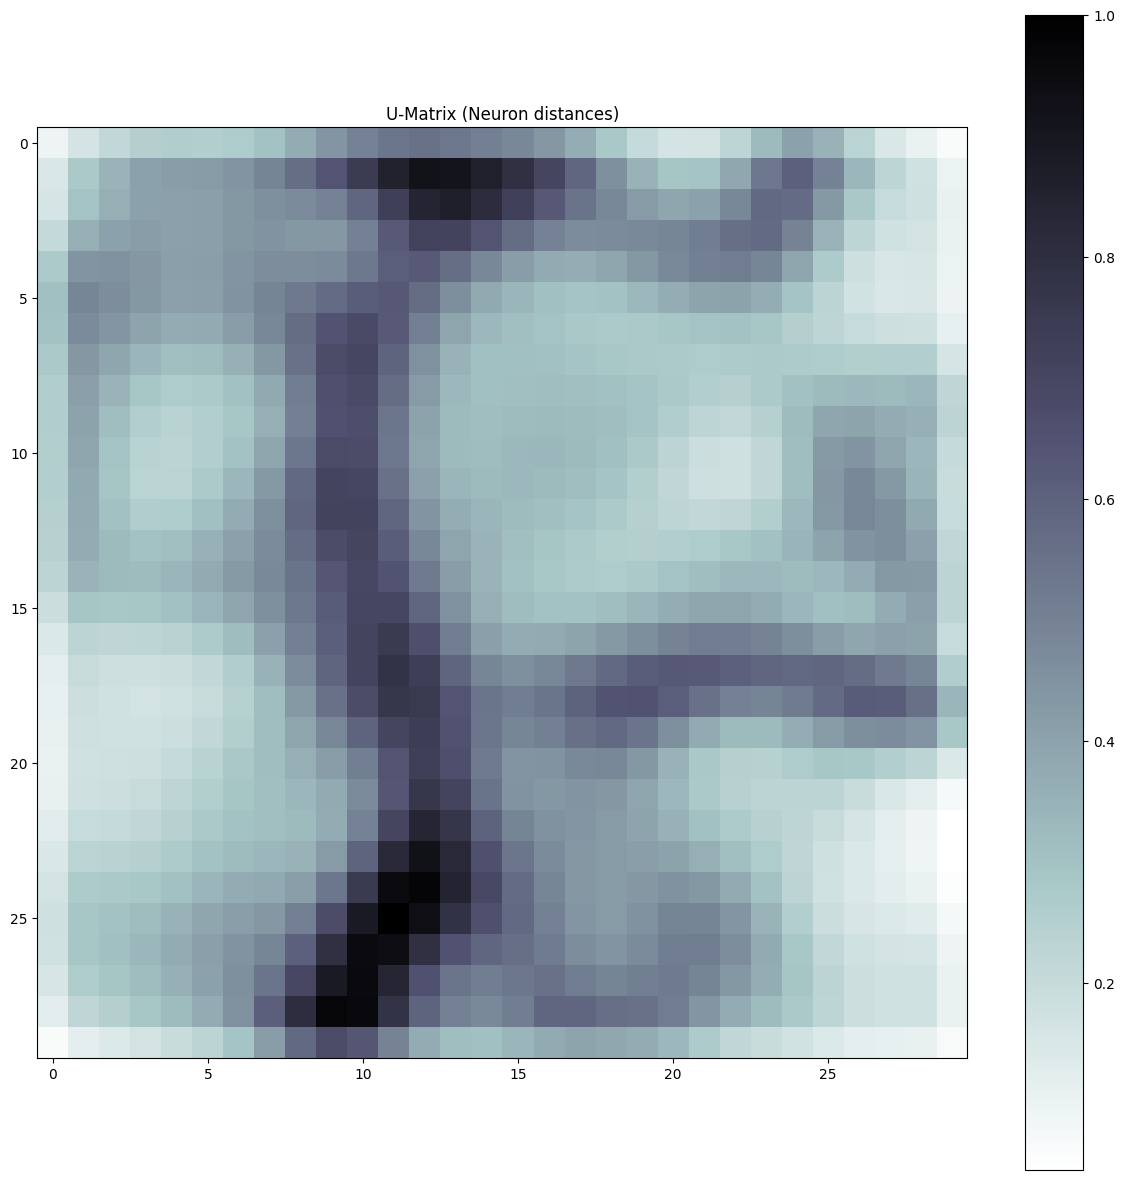

In [34]:
u_matrix = som_clas_200.get_u_matrix()

plt.figure(figsize=(15,15))
plt.imshow(u_matrix, cmap="bone_r")
plt.colorbar()
plt.title("U-Matrix (Neuron distances)")
plt.show()

In [62]:
cluster_map = som_clas_200.create_clusters(
    data=df_som,
    n_clusters=3,
    method="density"
)

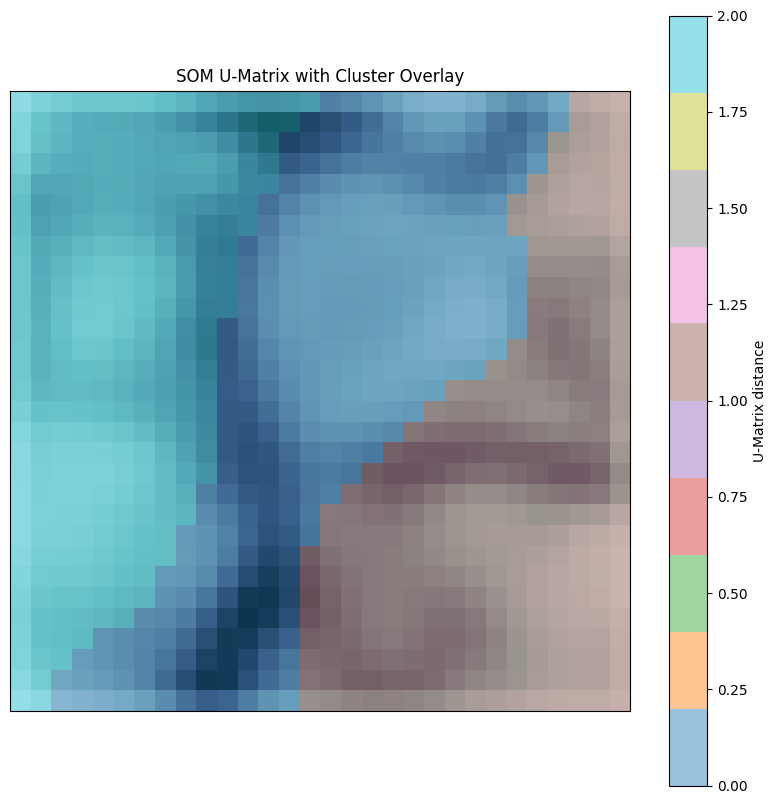

In [36]:
plt.figure(figsize=(10,10))

plt.imshow(u_matrix, cmap="bone_r")

plt.imshow(
    cluster_map,
    cmap="tab10",
    alpha=0.45
)

plt.colorbar(label="U-Matrix distance")

plt.title("SOM U-Matrix with Cluster Overlay")

plt.xticks([])
plt.yticks([])

plt.show()

**SOM Analysis Panel**

1. U-Matrix (Unified Distance Matrix)
The U-Matrix visualizes the average distance between neighboring neurons.

- Light areas → **similar neurons (clusters)**
- Dark areas → **large distances (cluster boundaries)**

2. Hit Map **(Activation Map)**
The hit map shows how many data samples are mapped to each neuron.

3. Cluster Map
Displays clustering results applied to SOM neurons (here using density-aware KMeans).

4. U-Matrix + Cluster Overlay
Combines structural information (U-Matrix) with clustering.

5. Feature Maps (Component Planes)

Each feature is visualized across the SOM grid using neuron weights.

Each feature map shows how that variable varies across the SOM:

- Smooth gradients → structured relationship  
- Sharp transitions → strong separation between regions  
- Uniform areas → low influence of that feature  

Feature maps help identify:

- Which variables drive clustering  
- Relationships between physiological signals  
- Correlations (e.g., HR vs HRV)  
- Regions of high/low activation  

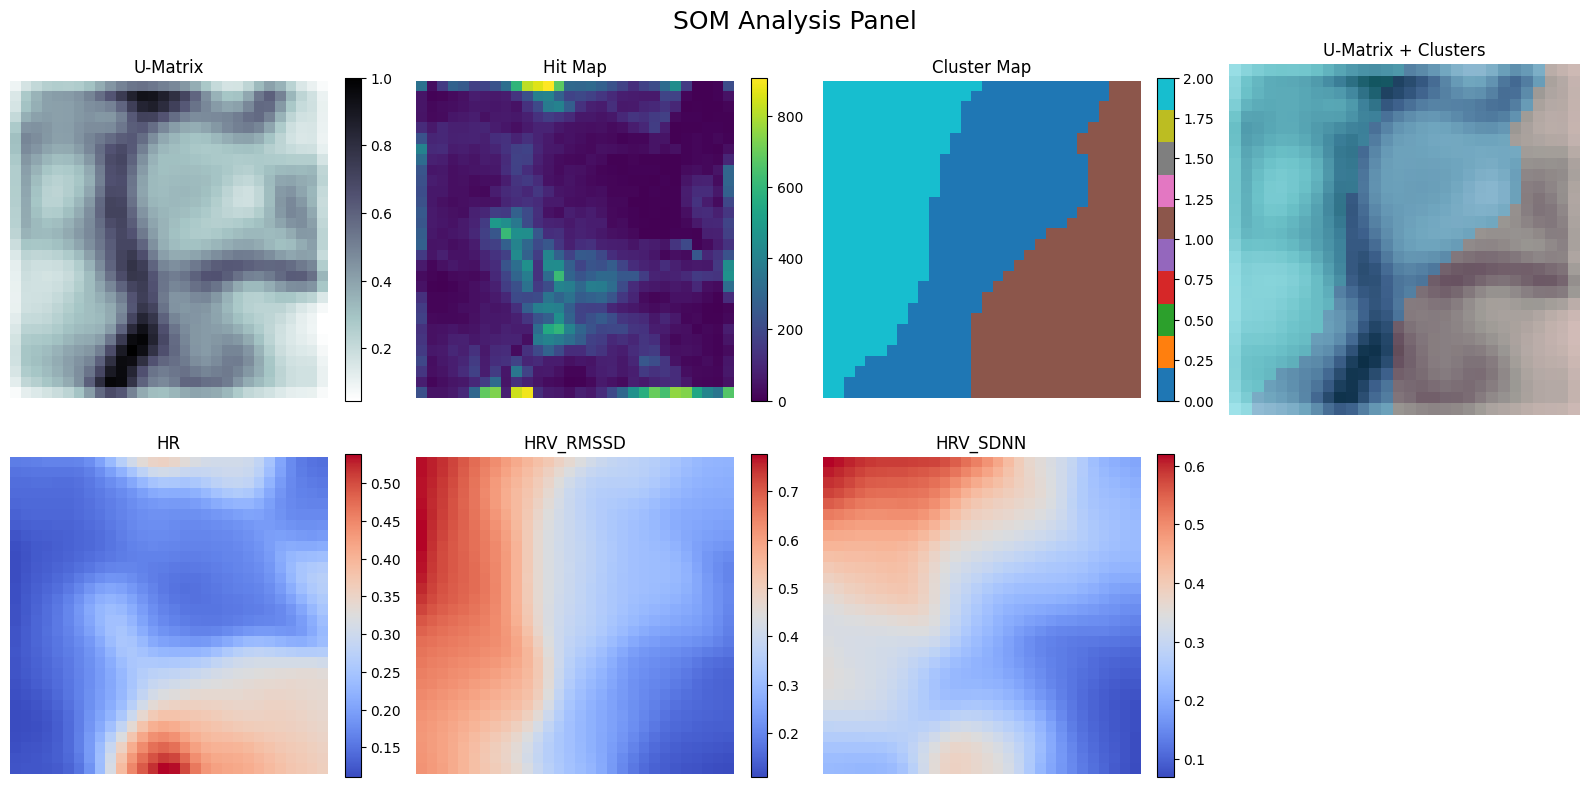

In [63]:
# ===== COMPLETE SOM VISUALIZATION PANEL =====

import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
scaled_data = som_clas_200.scaler.transform(df_som)

u_matrix = som_clas_200.get_u_matrix()

hits = som_clas_200.som.activation_response(scaled_data)

cluster_map = som_clas_200.create_clusters(
    data=df_som,
    n_clusters=3,
    method="density"
)

weights = som_clas_200.som.get_weights()

feature_names = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN"
  
]

# ---- Figure layout ----
fig = plt.figure(figsize=(16,12))

grid = fig.add_gridspec(3,4)

# ---- U-Matrix ----
ax1 = fig.add_subplot(grid[0,0])
im = ax1.imshow(u_matrix, cmap="bone_r")
ax1.set_title("U-Matrix")
ax1.axis("off")
plt.colorbar(im, ax=ax1, fraction=0.046)

# ---- Hit Map ----
ax2 = fig.add_subplot(grid[0,1])
im = ax2.imshow(hits, cmap="viridis")
ax2.set_title("Hit Map")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

# ---- Cluster Map ----
ax3 = fig.add_subplot(grid[0,2])
im = ax3.imshow(cluster_map, cmap="tab10")
ax3.set_title("Cluster Map")
ax3.axis("off")
plt.colorbar(im, ax=ax3, fraction=0.046)

# ---- U-Matrix + Cluster Overlay ----
ax4 = fig.add_subplot(grid[0,3])
ax4.imshow(u_matrix, cmap="bone_r")
ax4.imshow(cluster_map, cmap="tab10", alpha=0.4)
ax4.set_title("U-Matrix + Clusters")
ax4.axis("off")

# ---- Feature Maps ----
for i in range(3):

    row = 1 + i // 3
    col = i % 3

    ax = fig.add_subplot(grid[row, col])

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046)

# ---- Layout ----
plt.suptitle("SOM Analysis Panel", fontsize=18)
plt.tight_layout()
plt.show()

In [38]:
df["cluster"] = som_clas_200.predict_cluster(df_som)

cluster_profiles = df.groupby("cluster").mean()

cluster_profiles

print("Counts:")
print(df["cluster"].value_counts())

print("\nMeans:")
print(df.groupby("cluster").mean())

print("\nStd:")
print(df.groupby("cluster").std())




🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD    HRV_SDNN
0  93.828910  65.346708  130.900565
1  94.001809  63.111296  128.258724
2  94.701579  62.704837  120.651230
3  94.879177  64.111971  121.066798
4  95.510603  61.018147  123.878461
🔍 INPUT range:
min: HR           52.600662
HRV_RMSSD     8.021961
HRV_SDNN     10.176887
dtype: float64
max: HR           155.145444
HRV_RMSSD    100.415802
HRV_SDNN     170.593132
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.40205116 0.62043906 0.75256517]
 [0.40373723 0.59624467 0.7360965 ]
 [0.41056127 0.59184546 0.68867304]
 [0.41229318 0.60707521 0.6912636 ]
 [0.41845075 0.57359003 0.70879089]]
🔍 AFTER scaling range:
min: 0.0
max: 1.0000000000000002

🔍 Unique BMUs: 895
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}
Counts:
cluster
0    40385
2    32747
1    31844
Name: count, dtype: int64

Means:
                HR  HRV_RMSSD   HRV_SDNN
cluster                                 
0        78.295254  48.045568  55.838659
1        

In [39]:
cluster_profiles.describe()

,HR,HRV_RMSSD,HRV_SDNN
count,3.000000,3.000000,3.000000
mean,79.671126,47.532192,57.787092
std,7.015303,19.050544,22.789305
min,73.445690,28.230149,36.034559
25%,75.870472,38.137859,45.936609
50%,78.295254,48.045568,55.838659
75%,82.783845,57.183214,68.663358
max,87.272435,66.320860,81.488057


In [16]:
print("---- Scaling info ----")

print("Min:", scaled_data.min(axis=0))
print("Max:", scaled_data.max(axis=0))
print("----------------------")

---- Scaling info ----
Min: [0. 0. 0.]
Max: [1. 1. 1.]
----------------------


🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD    HRV_SDNN
0  93.828910  65.346708  130.900565
1  94.001809  63.111296  128.258724
2  94.701579  62.704837  120.651230
3  94.879177  64.111971  121.066798
4  95.510603  61.018147  123.878461
🔍 INPUT range:
min: HR           52.600662
HRV_RMSSD     8.021961
HRV_SDNN     10.176887
dtype: float64
max: HR           155.145444
HRV_RMSSD    100.415802
HRV_SDNN     170.593132
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.40205116 0.62043906 0.75256517]
 [0.40373723 0.59624467 0.7360965 ]
 [0.41056127 0.59184546 0.68867304]
 [0.41229318 0.60707521 0.6912636 ]
 [0.41845075 0.57359003 0.70879089]]
🔍 AFTER scaling range:
min: 0.0
max: 1.0000000000000002

🔍 Unique BMUs: 895
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}

=== MEAN PER CLUSTER ===


,HR,HRV_RMSSD,HRV_SDNN
cluster,,,
0,78.295254,48.045568,55.838659
1,87.272435,28.230149,36.034559
2,73.445690,66.320860,81.488057



=== STD PER CLUSTER ===


,HR,HRV_RMSSD,HRV_SDNN
cluster,,,
0,8.900904,7.329444,13.531583
1,11.485662,7.185276,11.384768
2,10.609823,8.806613,19.163691



=== FEATURE IMPORTANCE (normalized difference) ===


,HR,HRV_RMSSD,HRV_SDNN
0,0.103817,0.018403,0.085440
1,0.666174,1.158003,0.934109
2,0.519774,1.103375,1.013719


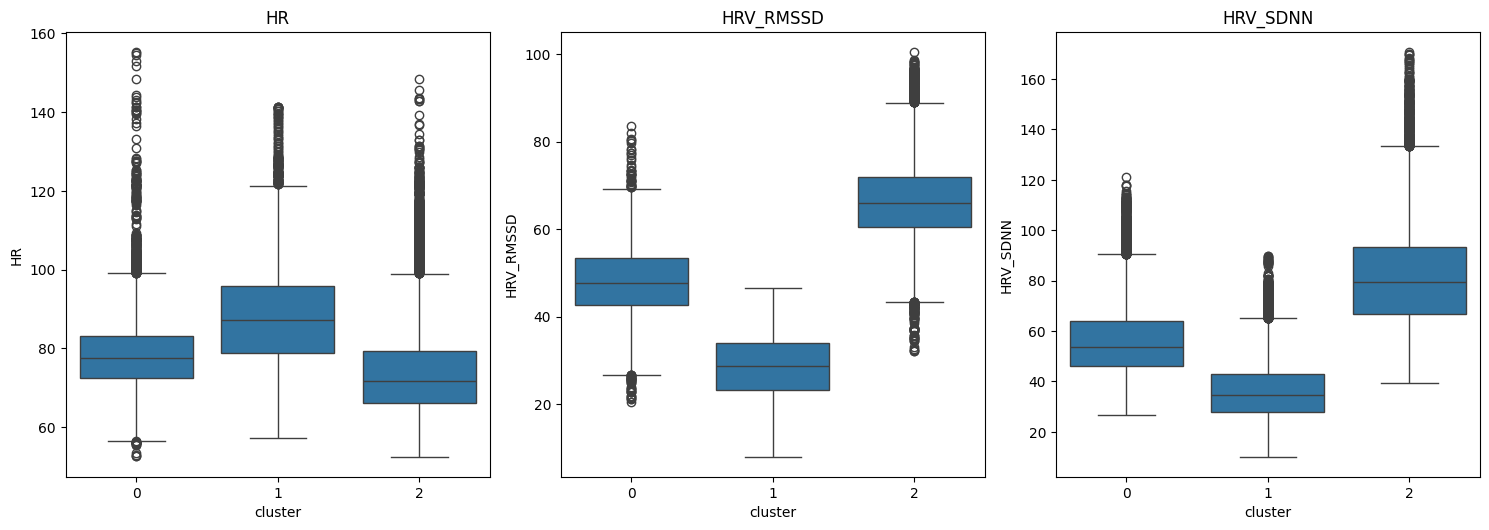


=== COHEN'S D BETWEEN CLUSTERS ===

Cluster 0 vs 1
HR: -0.87
HRV_RMSSD: 2.73
HRV_SDNN: 1.58

Cluster 0 vs 2
HR: 0.50
HRV_RMSSD: -2.26
HRV_SDNN: -1.55

Cluster 1 vs 2
HR: 1.25
HRV_RMSSD: -4.74
HRV_SDNN: -2.88


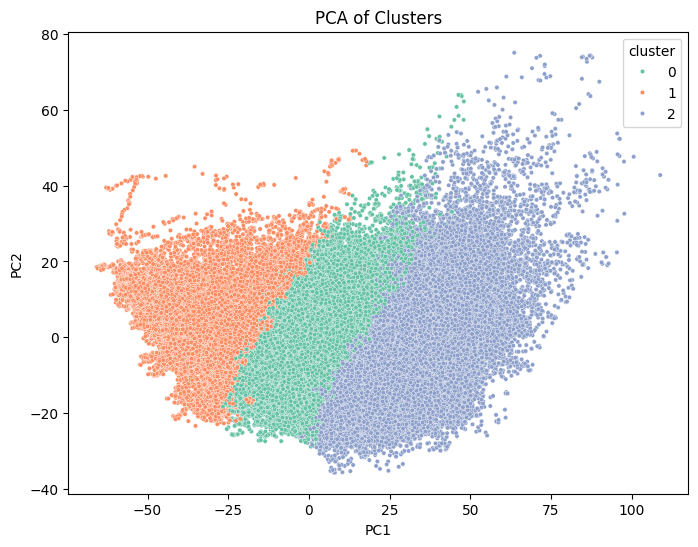

In [64]:
# ================================
# FULL CLUSTER ANALYSIS CELL
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from itertools import combinations

# -------------------------
# 1. DATAFRAME
# -------------------------
feature_names = ["HR", "HRV_RMSSD", "HRV_SDNN"]

df = pd.DataFrame(df_som, columns=feature_names)
df["cluster"] = som_clas_200.predict_cluster(df_som)

# -------------------------
# 2. BASIC STATS
# -------------------------
print("\n=== MEAN PER CLUSTER ===")
display(df.groupby("cluster").mean())

print("\n=== STD PER CLUSTER ===")
display(df.groupby("cluster").std())

# -------------------------
# 3. FEATURE IMPORTANCE
# -------------------------
print("\n=== FEATURE IMPORTANCE (normalized difference) ===")

global_mean = df[feature_names].mean()
global_std = df[feature_names].std()

importance = []

for c in sorted(df["cluster"].unique()):
    diff = abs(df[df.cluster == c][feature_names].mean() - global_mean) / global_std
    importance.append(diff)

importance_df = pd.DataFrame(importance, index=sorted(df["cluster"].unique()))
display(importance_df)

# -------------------------
# 4. BOXPLOTS
# -------------------------
plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_names):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x="cluster", y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

# -------------------------
# 5. COHEN'S D (EFFECT SIZE)
# -------------------------
def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x)**2 + np.std(y)**2) / 2)

print("\n=== COHEN'S D BETWEEN CLUSTERS ===")

for (c1, c2) in combinations(sorted(df.cluster.unique()), 2):
    print(f"\nCluster {c1} vs {c2}")
    for col in feature_names:
        d = cohens_d(df[df.cluster==c1][col], df[df.cluster==c2][col])
        print(f"{col}: {d:.2f}")

# -------------------------
# 6. PCA VISUALIZATION
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[feature_names])

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["cluster"], palette="Set2", s=10)
plt.title("PCA of Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [41]:
# ================================
# FEATURE RANKING PER CLUSTER
# ================================

import pandas as pd
import numpy as np

feature_names = ["HR", "HRV_RMSSD", "HRV_SDNN"]

# Global statistik
global_mean = df[feature_names].mean()
global_std = df[feature_names].std()

cluster_profiles = {}
ranking_rows = []

for c in sorted(df["cluster"].unique()):
    cluster_mean = df[df.cluster == c][feature_names].mean()
    
    # Normaliserad skillnad (importance score)
    importance = (cluster_mean - global_mean) / global_std
    
    # Absolut värde för ranking
    importance_abs = importance.abs().sort_values(ascending=False)
    
    # Spara topp-features
    top_features = importance_abs.index.tolist()
    
    for i, feat in enumerate(top_features):
        ranking_rows.append({
            "Cluster": c,
            "Rank": i+1,
            "Feature": feat,
            "Importance": importance[feat],
            "Abs Importance": importance_abs[feat]
        })

ranking_df = pd.DataFrame(ranking_rows)

# Visa topp 3 per kluster
print("\n=== TOP FEATURES PER CLUSTER ===")
display(ranking_df.groupby("Cluster").head(3))

# -------------------------
# BONUS: Pivot-tabell (snygg för rapport)
# -------------------------
pivot_table = ranking_df.pivot_table(
    index="Cluster",
    columns="Rank",
    values="Feature",
    aggfunc="first"
)

pivot_table.columns = [f"Rank {c}" for c in pivot_table.columns]

print("\n=== FEATURE RANKING TABLE ===")
display(pivot_table)


=== TOP FEATURES PER CLUSTER ===


,Cluster,Rank,Feature,Importance,Abs Importance
0,0,1,HR,-0.103817,0.103817
1,0,2,HRV_SDNN,-0.085440,0.085440
2,0,3,HRV_RMSSD,0.018403,0.018403
3,1,1,HRV_RMSSD,-1.158003,1.158003
4,1,2,HRV_SDNN,-0.934109,0.934109
5,1,3,HR,0.666174,0.666174
6,2,1,HRV_RMSSD,1.103375,1.103375
7,2,2,HRV_SDNN,1.013719,1.013719
8,2,3,HR,-0.519774,0.519774



=== FEATURE RANKING TABLE ===


,Rank 1,Rank 2,Rank 3
Cluster,,,
0,HR,HRV_SDNN,HRV_RMSSD
1,HRV_RMSSD,HRV_SDNN,HR
2,HRV_RMSSD,HRV_SDNN,HR


In [65]:
som_clas_200.set_cluster_labels({
    0: "Netrual/Base",
    1: "Stress",
    2: "Rest/Recovery"
})


In [66]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

som_clas_200.export_to_c(filepath=MODEL_DIR / "som_model_200hz_ver9_ppg_center.h")



C header exported to: ..\models\som_model_200hz_ver9_ppg_center.h


In [67]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "som_model_200hz_ver9_ppg_center.pkl"

som_clas_200.save_model(model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\som_model_200hz_ver9_ppg_center.pkl


In [46]:
features = ["HR", "HRV_RMSSD", "HRV_SDNN"]

X_train = df_som[features]

In [47]:
scaled_train = pd.DataFrame(
    som_clas_200.scaler.transform(X_train),
    columns=features,
    index=X_train.index
)

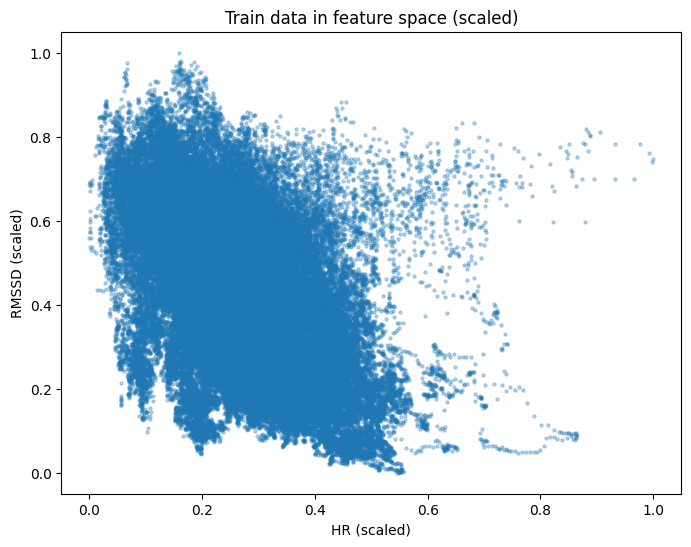

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_train["HR"],
    scaled_train["HRV_RMSSD"],
   
    s=5,
    alpha=0.3
)

plt.xlabel("HR (scaled)")
plt.ylabel("RMSSD (scaled)")
plt.title("Train data in feature space (scaled)")
plt.show()

In [49]:
print(df_som[features].head())
print(df_som[features].min())
print(df_som[features].max())

          HR  HRV_RMSSD    HRV_SDNN
0  93.828910  65.346708  130.900565
1  94.001809  63.111296  128.258724
2  94.701579  62.704837  120.651230
3  94.879177  64.111971  121.066798
4  95.510603  61.018147  123.878461
HR           52.600662
HRV_RMSSD     8.021961
HRV_SDNN     10.176887
dtype: float64
HR           155.145444
HRV_RMSSD    100.415802
HRV_SDNN     170.593132
dtype: float64


In [50]:
X_train = df_som[features]

X_train_scaled = pd.DataFrame(
    som_clas_200.scaler.transform(X_train),
    columns=features,
    index=X_train.index
)

df_som["cluster"] = som_clas_200.predict_cluster(X_train)

🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD    HRV_SDNN
0  93.828910  65.346708  130.900565
1  94.001809  63.111296  128.258724
2  94.701579  62.704837  120.651230
3  94.879177  64.111971  121.066798
4  95.510603  61.018147  123.878461
🔍 INPUT range:
min: HR           52.600662
HRV_RMSSD     8.021961
HRV_SDNN     10.176887
dtype: float64
max: HR           155.145444
HRV_RMSSD    100.415802
HRV_SDNN     170.593132
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.40205116 0.62043906 0.75256517]
 [0.40373723 0.59624467 0.7360965 ]
 [0.41056127 0.59184546 0.68867304]
 [0.41229318 0.60707521 0.6912636 ]
 [0.41845075 0.57359003 0.70879089]]
🔍 AFTER scaling range:
min: 0.0
max: 1.0000000000000002

🔍 Unique BMUs: 895
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}


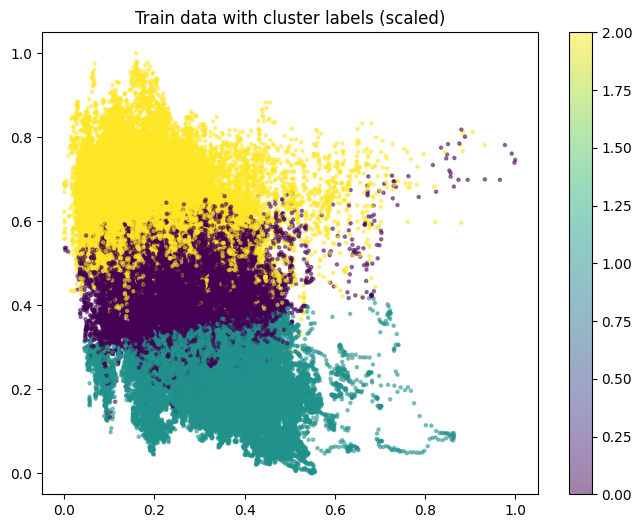

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_train["HR"],
    scaled_train["HRV_RMSSD"],
    c=df_som["cluster"],
    s=5,
    alpha=0.5
)

plt.title("Train data with cluster labels (scaled)")
plt.colorbar()
plt.show()

In [25]:
print(df_som.columns)
print("cluster" in df_som.columns)
print(len(df_som), len(scaled_train))

Index(['HR', 'HRV_RMSSD', 'HRV_SDNN', 'cluster'], dtype='str')
True
108428 108428


In [26]:
weights = som_clas_200.som.get_weights().reshape(-1, 3)

print("Unique cluster labels on neurons:")
print(set(som_clas_200.kmeans.labels_))

Unique cluster labels on neurons:
{np.int32(0), np.int32(1), np.int32(2)}
